Yeom's request: 
1) phase map을 그리자
2) 통계 추정치를 뽑아내자.

# Load Data

In [1]:
from useful import auto199

In [2]:
import imagingPhase.load_data as ld
fn = './phaseAnalysis3/2HTaSe_cab_110K006_better_process.gwy'
import gwyfile
import numpy as np
container = gwyfile.load(fn)
arr = container['/0/data']['data']
arr = arr.reshape([1024,1024])
print('I can read the variables in outside')


imagingPhase package loaded
Directory of data: ./phaseAnalysis
list of files ['2HTaSe2_ah035', '2HTaSe2_aj036', '2HTaSe2_ao_115K037', '2HTaSe2_ap_118K002', '2HTaSe2_bad_78K097', '2HTaSe2_bad_78K100', '2HTaSe2_bae_110K012', '2HTaSe2_bae_110K013']
                                fileName_ntn             Comments_ntn  \
fileName_no_ext                                                         
2HTaSe2_ah035              2HTaSe2_ah035.sxm  1st 110K manual anlysis   
2HTaSe2_aj036              2HTaSe2_aj036.sxm  1st 110K manual anlysis   
2HTaSe2_ao_115K037         2HTaSe2_ao037.sxm  1st 110K manual anlysis   
2HTaSe2_ap_118K002         2HTaSe2_ap002.sxm  1st 110K manual anlysis   
2HTaSe2_bad_78K097    2HTaSe2_bad_78K097.sxm           most clean 160   
2HTaSe2_bad_78K100    2HTaSe2_bad_78K100.sxm                      NaN   
2HTaSe2_bae_110K012  2HTaSe2_bae_110K012.sxm          best 80nm ICCDW   
2HTaSe2_bae_110K012  2HTaSe2_bae_110K012.sxm                      NaN   
2HTaSe2_bae_110K013  2HT

# Quick preprocess

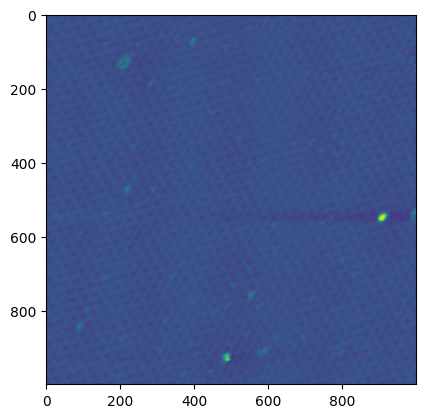

In [3]:
from matplotlib import pyplot as plt
plt.imshow(arr[0:1000,0:1000])

In [4]:
from scipy.ndimage import gaussian_filter
def ceilcut(arr2,threshold=1*10**-10):
  arr2[arr2>threshold] = threshold
  return arr2
def highpass(arr2,sigma=5):
  
  arr2 = arr2 - gaussian_filter(arr2,sigma=sigma)
  return arr2



In [5]:
print(arr.flatten().max())
print(arr.flatten().min())

1.6433732449890205e-10
-8.548774548603105e-11


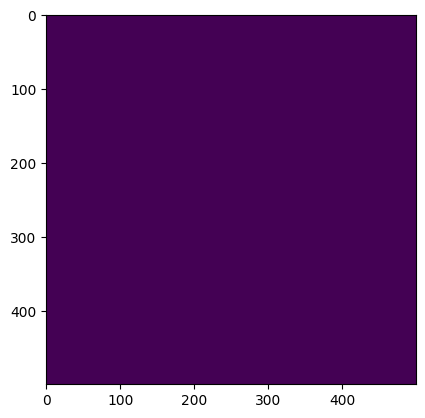

In [6]:
# plt.hist(arr.flatten().max)
plt.imshow(arr[0:500,0:500]>1*10**-10)

d:\github\2H_TaSe2_Tc_STM\2Hvenv\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


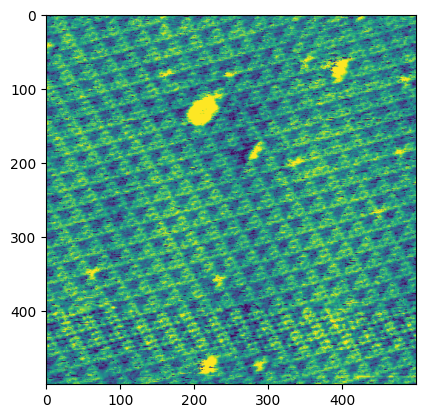

In [7]:
plt.imshow(arr[0:500,0:500])
auto199()

In [8]:
arr_after = highpass(ceilcut(arr)) 

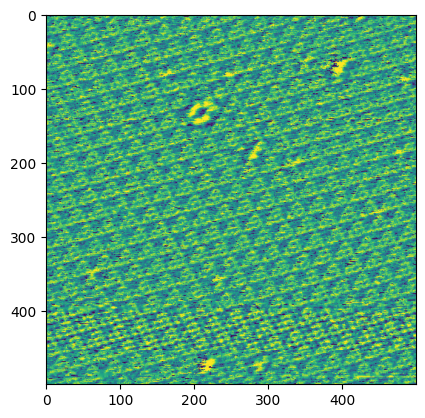

In [9]:
plt.imshow(arr_after[0:500,0:500])
auto199()

In [10]:
# from scipy.fft import fft2, fftshift
# from skimage.feature import peak_local_max
# def fft2show(arr_cln,vmin,vmax):
#   fft_result = fft2(arr_cln)
#   fft_result_shifted = fftshift(fft_result)
#   magnitude_spectrum = np.abs(fft_result_shifted)
#   plt.figure(figsize=(10, 10))
#   plt.imshow(magnitude_spectrum, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.title('Magnitude Spectrum of 2D FFT')
#   return  magnitude_spectrum
# def fft2pkfnd(fft2abs,threshold,choose):
#   coordinates = peak_local_max(fft2abs, min_distance=100, threshold_abs = threshold)
#   plt.scatter(coordinates[:, 1], coordinates[:, 0], s=50, facecolors='none', edgecolors='r')
#   for ipeak in range(coordinates.shape[0]):
#     plt.text(coordinates[ipeak,1],coordinates[ipeak,0],str(ipeak), color='g')
#   coordinates_choose = coordinates[choose,:]
#   print(coordinates_choose)
#   print(coordinates_choose.shape[0])
#   for ipeak in range(coordinates_choose.shape[0]):
#     plt.text(coordinates_choose[ipeak,1],coordinates_choose[ipeak,0],str(ipeak), color='b',size= 20)
#     pk_all = coordinates - (np.array(fft2abs.shape)/2)
#     pk_choose = pk_all[choose,:]
#   return pk_choose,pk_all
arr_cln = arr_after

In [39]:
vmin = 0 # @param
vmax = 0.0000001 # @param
threshold = 0.00000002 # @param
choose = [14,1,10] # @param

In [12]:
from imagingPhase.ffts import fft2show,fft2pkfnd

In [13]:
from imagingPhase.ffts import fft2show,fft2pkfnd

In [14]:
fft2show

<function imagingPhase.ffts.fft2show(arr_cln, vmin=None, vmax=None)>

[[438 383]
 [635 547]
 [460 605]]
3
[[ -74. -129.]
 [ 123.   35.]
 [ -52.   93.]]
[[-123.  -35.]
 [ 123.   35.]
 [ -42.  -12.]
 [  42.   12.]
 [ -24.  -43.]
 [  24.   43.]
 [ -17.   30.]
 [  17.  -30.]
 [-356.   12.]
 [ 356.  -12.]
 [ -52.   93.]
 [  52.  -93.]
 [ -85.  -23.]
 [  85.   23.]
 [ -74. -129.]
 [  74.  129.]
 [ -76.   50.]
 [  76.  -50.]
 [ -66.  -55.]
 [  66.   55.]
 [ -49.  -86.]
 [  49.   86.]
 [-256.   71.]
 [ 256.  -71.]
 [-119.   71.]
 [ 119.  -71.]
 [-329.   71.]
 [ 329.  -71.]
 [-399.  -12.]
 [ 399.   12.]
 [-283.  -71.]
 [ 283.   71.]
 [-392.  -71.]
 [ 392.   71.]
 [-325.   12.]
 [ 325.  -12.]
 [-324.  205.]
 [ 324. -205.]
 [-236.  -71.]
 [ 236.   71.]
 [-162.  102.]
 [ 162. -102.]
 [-173.   70.]
 [ 173.  -70.]
 [-272.   12.]
 [ 272.  -12.]
 [-463.  -71.]
 [ 463.   71.]
 [-460.   42.]
 [ 460.  -42.]
 [-341.  -45.]
 [ 341.   45.]
 [-184.    1.]
 [ 184.   -1.]]


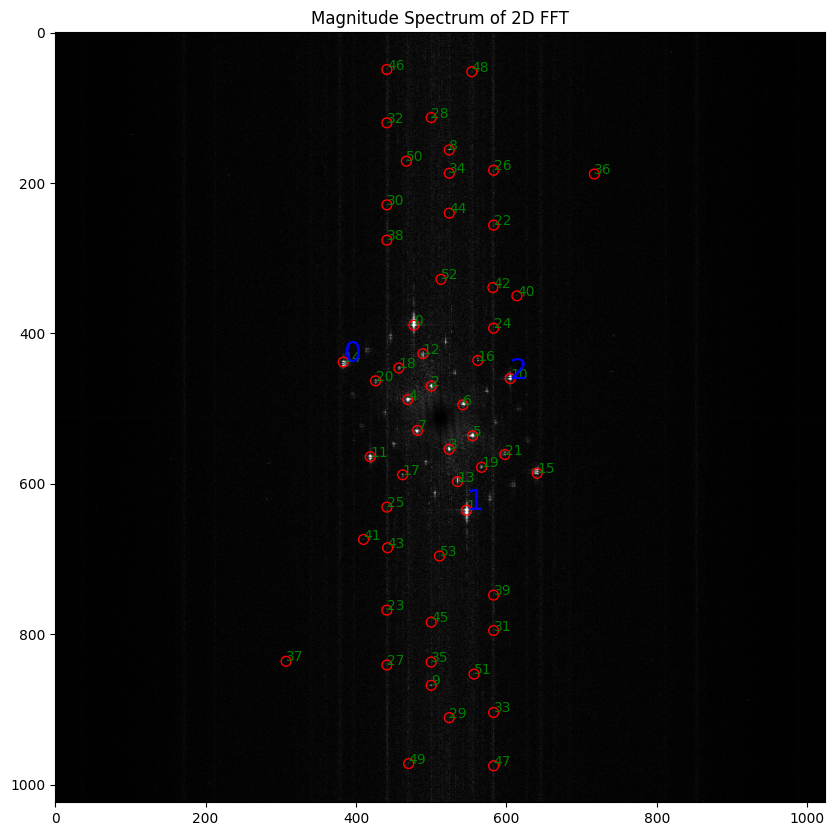

In [40]:
# from imagingPhase import fft2show
fft2abs = fft2show(arr_cln,vmin,vmax)
pk_choose,pk_all = fft2pkfnd(fft2abs,threshold,choose,min_distance=30)
print(pk_choose)
print(pk_all)

Text(0.5, 0.98, 'k0')

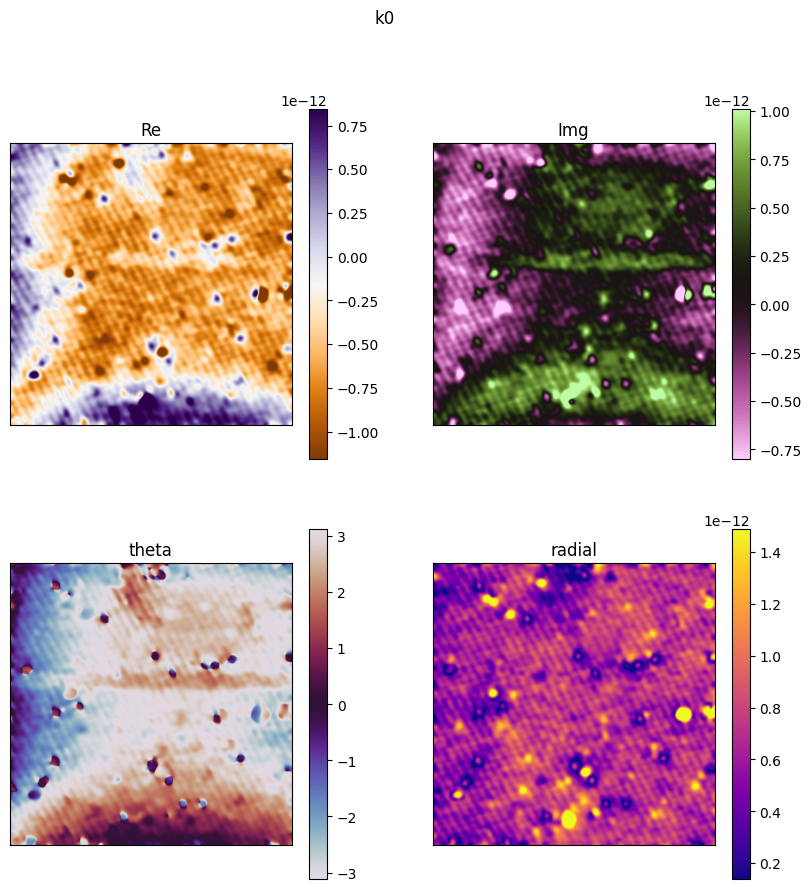

In [41]:
from imagingPhase.get_phimap import kdisplacementmap, visxprod

ik = 0 # @param
k = pk_choose[ik]/3
sig = 10 # @para
xprod = kdisplacementmap(arr_cln,k,sig)
visxprod(xprod)
plt.suptitle("k"+str(ik))


In [42]:
ks_Latt = pk_choose
ks_CDW = pk_choose/3

In [44]:
def wrap_phase(unwrapped_phase):
  """
  Wraps unwrapped phase data into the range of (-pi, pi].

  Args:
    unwrapped_phase: A numpy array containing the unwrapped phase data.

  Returns:
    A numpy array containing the wrapped phase data.
  """
  wrapped_phase = np.mod(unwrapped_phase + np.pi, 2 * np.pi) - np.pi
  return wrapped_phase
from skimage.restoration import unwrap_phase

In [45]:

sig = 20 # @param
angle_restores = []
complexs = []
for ik in range(3):
  k_Latt = ks_Latt[ik]
  k_CDW = ks_CDW[ik]
  complex = kdisplacementmap(arr_cln,k_CDW,sig)
  angle_restore = (unwrap_phase(np.angle(complex))- unwrap_phase(np.angle(kdisplacementmap(arr_cln,k_Latt,sig)))/3)
  angle_restores.append(angle_restore)
  complexs.append(complex)




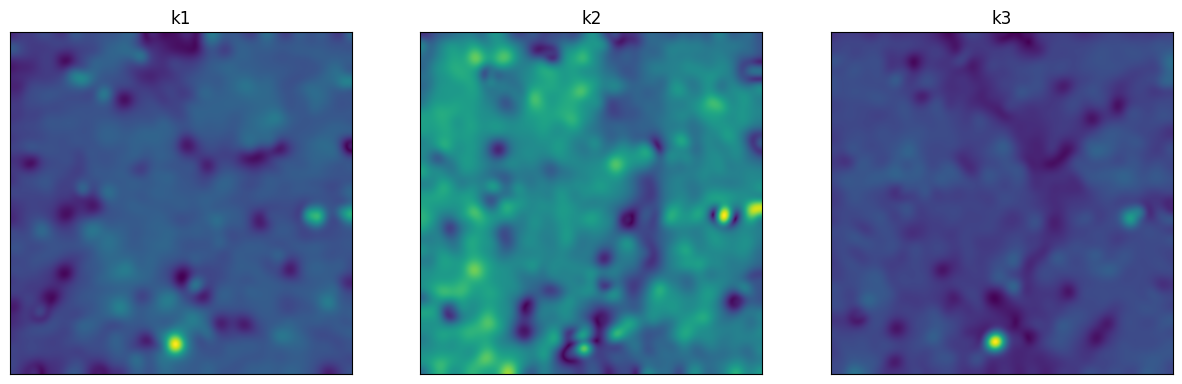

In [46]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.abs(complexs[ik])
    axs[ik].imshow(reimg)
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

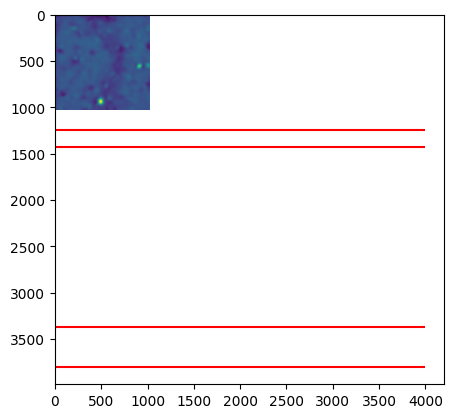

In [47]:
y_surgerys = [1250,1425,3375,3800]
reimg = np.abs(complexs[0])+np.abs(complexs[1])+np.abs(complexs[2])
plt.imshow(reimg)
plt.hlines(y_surgerys,xmin=0,xmax=4000,color='r')

d:\github\2H_TaSe2_Tc_STM\2Hvenv\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


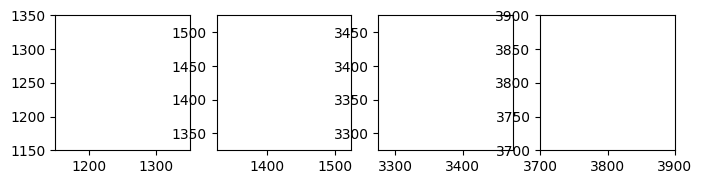

In [48]:
from IPython.core.pylabtools import figsize
l_half = 100
msb,nsb = 1,4
fig,axs = plt.subplots(1,4,figsize=(8,2))
for jsb,ax,y_surgery in zip(range(4),axs,y_surgerys):     
    ax.imshow(arr_cln)
    plt.sca(ax)
    auto199()
    ax.set_xlim([y_surgery-l_half,y_surgery+l_half])
    ax.set_ylim([y_surgery-l_half,y_surgery+l_half])
    
    
        

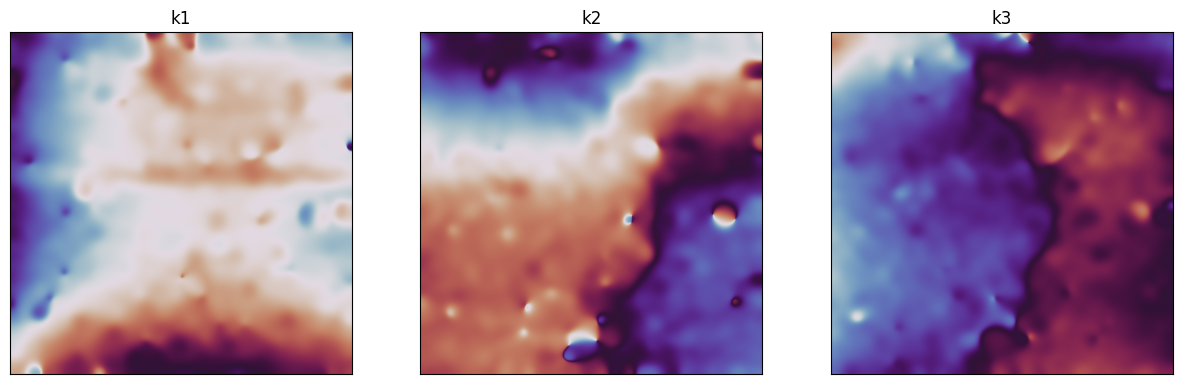

In [49]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.angle(complexs[ik])
    axs[ik].imshow(reimg,cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

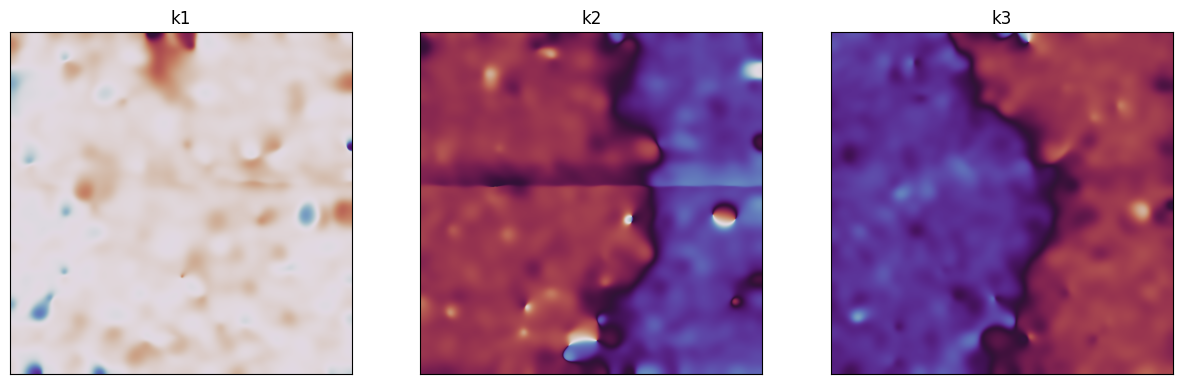

In [50]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
for ik,tn in zip(range(3),tns):
    reimg = angle_restores[ik]
    reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

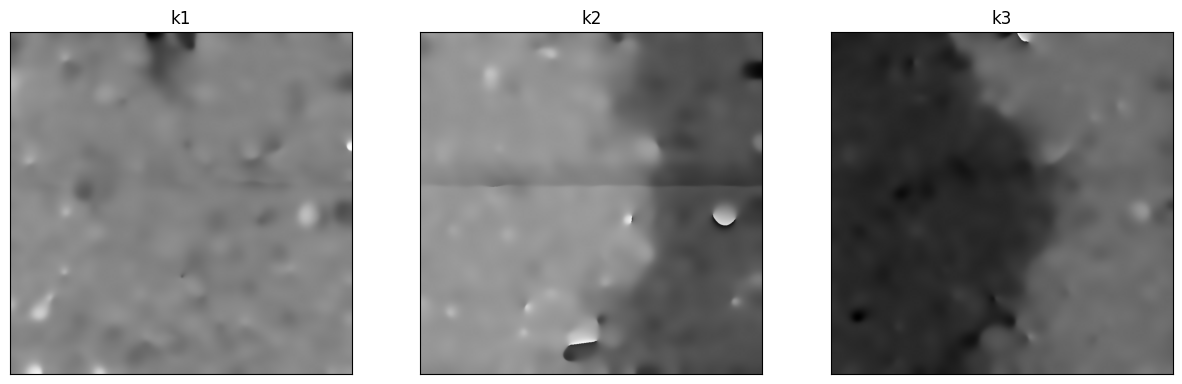

In [51]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
for ik,tn in zip(range(3),tns):
    reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg,cmap='gray')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

In [26]:
lin = np.arange(4096)
y_surgerys
step1 = (lin>y_surgerys[1])*np.pi*(2/3)- np.pi*(2/3)
step2 = (lin>y_surgerys[0])*np.pi*(2/3)*3 +(lin>y_surgerys[1])*np.pi*(2/3)*2+(lin>y_surgerys[2])*np.pi*(2/3)*2
step3 = (lin>y_surgerys[0])*np.pi*(2/3)*3 +(lin>y_surgerys[2])*np.pi*(2/3)
steps = [step1,step2,step3]

# print(foo)

ValueError: operands could not be broadcast together with shapes (1024,1024) (4096,1) 

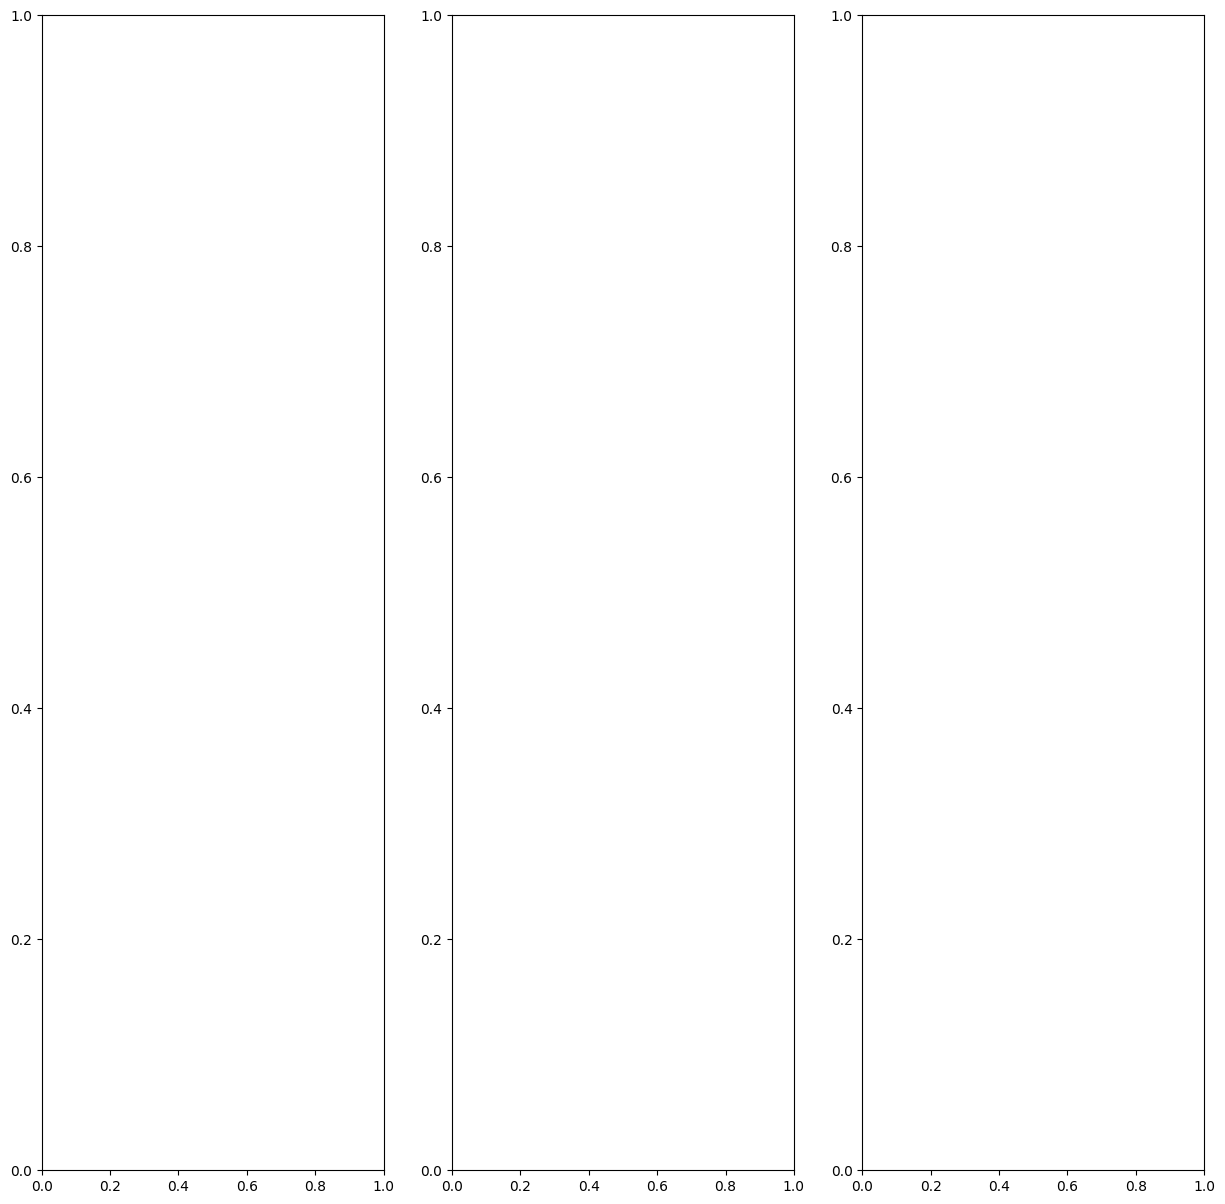

In [27]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
phase = []
for ik,tn,step in zip(range(3),tns,steps):
    reimg = angle_restores[ik]+step.reshape(4096,1)
    phase.append(reimg)
    reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

(array([218944., 219589., 220098., 220575., 216575., 215048., 214542.,
        211227., 206640., 204209., 198973., 197580., 193400., 186171.,
        180463., 175527., 166040., 156563., 148572., 142610., 137349.,
        131077., 125614., 121278., 114879., 108210., 102332.,  98504.,
         94538.,  90669.,  87280.,  84385.,  82061.,  78212.,  76984.,
         73320.,  70877.,  69018.,  66805.,  63622.,  61302.,  59236.,
         56837.,  54928.,  53452.,  51300.,  49586.,  47735.,  45881.,
         44119.,  42987.,  41730.,  40299.,  38830.,  37568.,  36380.,
         35417.,  34295.,  33157.,  31851.,  31076.,  29833.,  28722.,
         27415.,  26427.,  25861.,  25310.,  24091.,  23097.,  22446.,
         21984.,  21709.,  20921.,  20197.,  19569.,  18817.,  18522.,
         17813.,  17338.,  16937.,  16563.,  15949.,  15536.,  15100.,
         14548.,  14185.,  13871.,  13561.,  13046.,  12551.,  12380.,
         11718.,  11430.,  11154.,  11054.,  10520.,  10248.,  10164.,
      

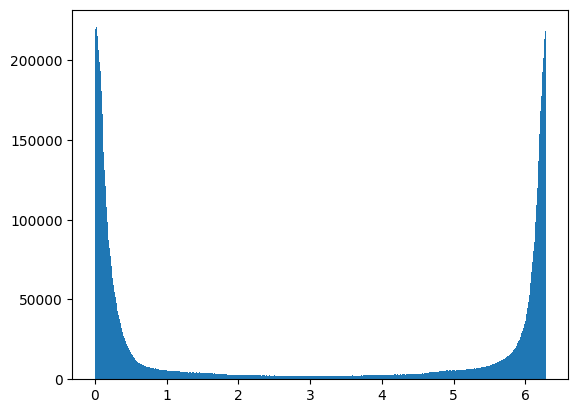

In [ ]:
g0,g1 = -.92,-.98
gs = [g0,g1]
phase_fixed = [phase[0]+g0,phase[1]+g1]
ik = 1
plt.hist(np.mod(3*(phase_fixed[ik].flatten()),np.pi*2),bins=1000)

In [ ]:
from imagingPhase.visPhase import phiPrinter
pp = phiPrinter([phase_fixed[0],phase_fixed[1]])

phase uploaded
phase calculated


(array([ 26580.,  26135.,  25121.,  24319.,  23947.,  22970.,  22178.,
         22035.,  21165.,  20906.,  20072.,  19249.,  18700.,  18166.,
         17899.,  17228.,  17077.,  16623.,  15965.,  16033.,  15620.,
         15280.,  14728.,  14794.,  14287.,  13890.,  13658.,  13578.,
         13166.,  12975.,  12713.,  12442.,  12373.,  12139.,  12076.,
         11554.,  11562.,  11424.,  11361.,  11242.,  11227.,  10987.,
         10618.,  10680.,  10374.,  10090.,  10113.,   9963.,   9837.,
          9950.,   9587.,   9510.,   9349.,   9328.,   9076.,   8951.,
          8705.,   8497.,   8361.,   8272.,   8237.,   8118.,   8177.,
          7946.,   7728.,   7878.,   7708.,   7636.,   7563.,   7476.,
          7541.,   7400.,   7393.,   7130.,   6997.,   6937.,   6814.,
          6673.,   6681.,   6808.,   6655.,   6526.,   6484.,   6556.,
          6464.,   6521.,   6370.,   6255.,   6242.,   6149.,   6059.,
          6127.,   6045.,   5885.,   5839.,   5776.,   5847.,   5520.,
      

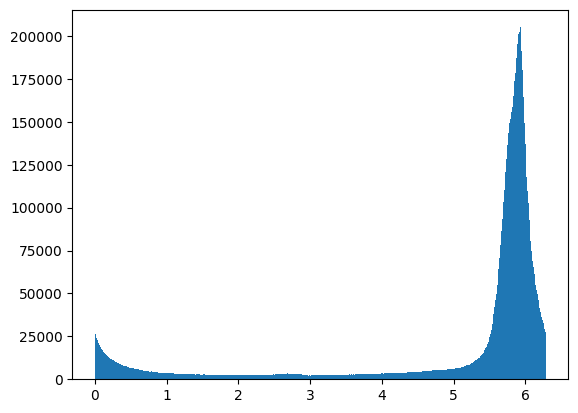

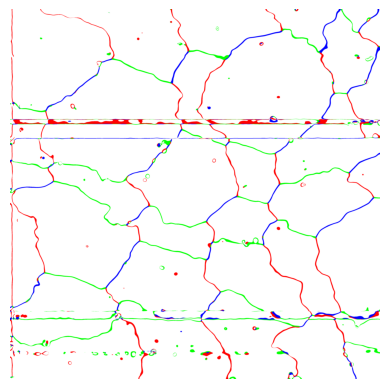

In [ ]:
from imagingPhase.visPhase import DWallColoring
dwc = DWallColoring(pp.Info,pp.phase)
dwc.show()